# Selección del Modelo

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import f1_score

In [ ]:
df = pd.read_csv('bankloan.csv')
df

,id,age,experience,income,zip,family,ccavg,education,mortgage,personal_loan,securities_account,cd_account,online,credit_card
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0


File contains 14 columns and 5000 rows. Description of the columns are as follows:

ID: Customer ID

Age : Customer Age

Experience : Customer Experience

Income : Income of the Customer

ZipCode: Customer's residence zipcode

Family : No of Family members of the customer

CCAvg: Credit Card Average Score

Education: Education of the customer

Mortgage: Mortgage taken or not taken by the customer

Personal Loan: 0 = No personal loan given , 1 = personal loan given

Securities Account : Having or not having a Securities Account

CD Account : Having or not having a CD Account

Online : Having or not having online banking

Credit Card : Having or not having a credit card

*Predecir si le darán crédito o no*

In [ ]:
# Variables no útiles en este ejercicio
df=df.drop(["id"],axis=1)
df=df.drop(["zip"],axis=1)
df

,age,experience,income,family,ccavg,education,mortgage,personal_loan,securities_account,cd_account,online,credit_card
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,1,1.9,3,0,0,0,0,1,0
4996,30,4,15,4,0.4,1,85,0,0,0,1,0
4997,63,39,24,2,0.3,3,0,0,0,0,0,0
4998,65,40,49,3,0.5,2,0,0,0,0,1,0


In [ ]:
df.isnull().sum()

,0
age,0
experience,0
income,0
family,0
ccavg,0
education,0
mortgage,0
personal_loan,0
securities_account,0
cd_account,0


In [ ]:
# Cantidad de datos
len(df)

5000

CONJUNTO DE VALIDACIÓN -> SACAR LOS PÁRAMETROS DEL MODELO (gamma, C, landa, profundidad de árboles)
- 60% ENTRENAMIENTO
- 20% VALIDAR
- 20% PROBAR

In [ ]:
# Dividimos el conjunto de datos para trabajar
X = df.drop(['personal_loan'], axis=1)
y = df['personal_loan']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42) #0.5 -> del 40% -> 20% y 20%

In [ ]:
#BOSQUE CON 5 HOJAS
from sklearn.ensemble import RandomForestClassifier

# Modelo entrenado con el conjunto de datos sin escalar
clf_rnd = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1) #n_jobs -> numero de procesadores
clf_rnd.fit(X_train, y_train)

#n_estimators ->árboles
#max_depth -> hojas

RandomForestClassifier(max_depth=10, n_estimators=50, n_jobs=-1,
                       random_state=42)

In [ ]:
# Predecimos con el conjunto de datos de validación
y_pred = clf_rnd.predict(X_val)
print("F1 Score:", f1_score(y_pred, y_val, average='weighted'))

F1 Score: 0.9882607100746756


In [ ]:
# Usamos el conjunto de prueba
y_pred = clf_rnd.predict(X_test)
print("F1 Score:", f1_score(y_pred, y_test, average='weighted'))

F1 Score: 0.9901483335146701


###  MALLA DE PARÁMETROS

In [ ]:
# Uso de Grid Search para selección del modelo
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [5,10,15],  #TAMAÑOS DE LOS BOSQUES
     'max_depth': [3, 6, 9], #PROFUNDIDADES
     'min_samples_split' : [2, 3, 4] #MÍNIMO DE LOS QUE QUIEO EN CADA HOJA
     }
  ]

rnd_clf = RandomForestClassifier(n_jobs=-1, random_state=42)
grid_search = GridSearchCV(rnd_clf, param_grid, cv=5,
                           scoring='f1_weighted', return_train_score=True)  #f1_weighted' ES EL QUE INDICA EL MEJOR

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             param_grid=[{'max_depth': [3, 6, 9],
                          'min_samples_split': [2, 3, 4],
                          'n_estimators': [5, 10, 15]}],
             return_train_score=True, scoring='f1_weighted')

***min_samples_split**: indica número mínimo de observaciones que debe tener una hoja para seguir creando nuevos nodos*

**BAGGIN VS BOOSTING**

![image.png]()

In [ ]:
grid_search.best_params_

{'max_depth': 9, 'min_samples_split': 2, 'n_estimators': 15}

In [ ]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print("F1 score:", mean_score, "-", "Parámetros:", params)

F1 score: 0.9470161783186031 - Parámetros: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 5}
F1 score: 0.9534554984685405 - Parámetros: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 10}
F1 score: 0.9375611467395004 - Parámetros: {'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 15}
F1 score: 0.9470161783186031 - Parámetros: {'max_depth': 3, 'min_samples_split': 3, 'n_estimators': 5}
F1 score: 0.9534554984685405 - Parámetros: {'max_depth': 3, 'min_samples_split': 3, 'n_estimators': 10}
F1 score: 0.9375611467395004 - Parámetros: {'max_depth': 3, 'min_samples_split': 3, 'n_estimators': 15}
F1 score: 0.9470161783186031 - Parámetros: {'max_depth': 3, 'min_samples_split': 4, 'n_estimators': 5}
F1 score: 0.9534554984685405 - Parámetros: {'max_depth': 3, 'min_samples_split': 4, 'n_estimators': 10}
F1 score: 0.9375611467395004 - Parámetros: {'max_depth': 3, 'min_samples_split': 4, 'n_estimators': 15}
F1 score: 0.9679723025113244 - Parámetros: {'max_depth': 6, 'min_sa

En este método el prueba solo
-  ***MALLA ALEATORIA***

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
        'n_estimators': randint(low=1, high=200),
        'max_depth': randint(low=8, high=50)
    }

rnd_clf = RandomForestClassifier(n_jobs=-1)

rnd_search = RandomizedSearchCV(rnd_clf, param_distributions=param_distribs,
                                n_iter=5, cv=2, scoring='f1_weighted')

rnd_search.fit(X_train, y_train)

RandomizedSearchCV(cv=2, estimator=RandomForestClassifier(n_jobs=-1), n_iter=5,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x797088d259a0>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79708ea1a2d0>},
                   scoring='f1_weighted')

In [ ]:
rnd_search.best_params_

{'max_depth': 27, 'n_estimators': 181}

In [ ]:
cvres = rnd_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print("F1 score:", mean_score, "-", "Parámetros:", params)

F1 score: 0.982985718921348 - Parámetros: {'max_depth': 48, 'n_estimators': 40}
F1 score: 0.9833781629266904 - Parámetros: {'max_depth': 22, 'n_estimators': 132}
F1 score: 0.9837378851448462 - Parámetros: {'max_depth': 27, 'n_estimators': 181}
F1 score: 0.9815948818349166 - Parámetros: {'max_depth': 42, 'n_estimators': 105}
F1 score: 0.9819250014716463 - Parámetros: {'max_depth': 32, 'n_estimators': 179}


In [ ]:
# Seleccionamos el mejor bosque y lo guarda en la variables 'modelo'
modelo = rnd_search.best_estimator_

In [ ]:
# Precisión del modelo final
y_pred = modelo.predict(X_test)
print("F1 Score:", f1_score(y_pred, y_test, average='weighted'))

F1 Score: 0.9891915417067844


# Selección de Variables

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import f1_score

In [ ]:
df = pd.read_csv('bankloan.csv')
df=df.drop(["id"],axis=1)
df=df.drop(["zip"],axis=1)

## Usando correlaciones

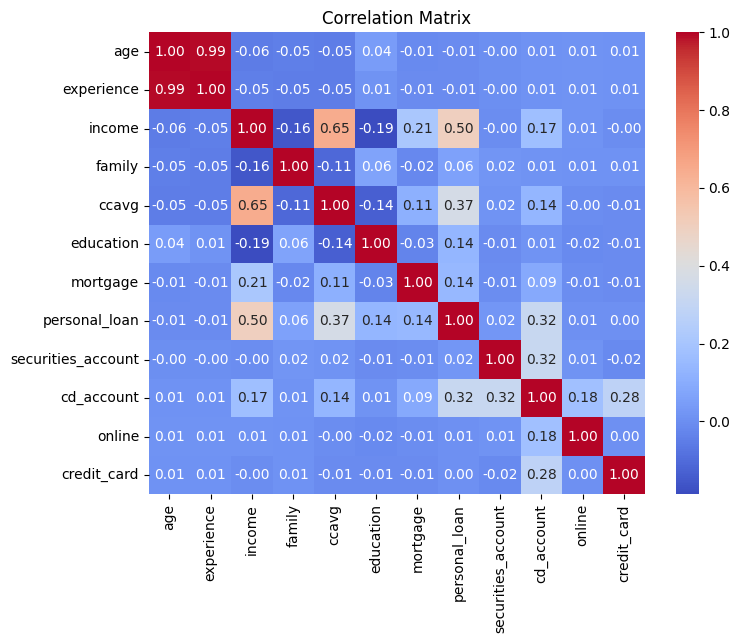

In [ ]:
correlation_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

- Cuando dos variables están muy relacionadas, una va salir del modelo (en regresión lineal)

> Me quedo con las variables más correlacionadas con lo que estoy tratando de predecir (personal_loan)



In [ ]:
# Calcular las correlaciones en valor absoluto
correlations = df.corr()['personal_loan'].abs().sort_values(ascending=False)
correlations = correlations.drop('personal_loan')
correlations

,personal_loan
income,0.502462
ccavg,0.366889
cd_account,0.316355
mortgage,0.142095
education,0.136722
family,0.061367
securities_account,0.021954
age,0.007726
experience,0.007413
online,0.006278


DIAGRAMA DE PARETO -> 80% 20%
* EL 2O% EXPLICA EL 80%


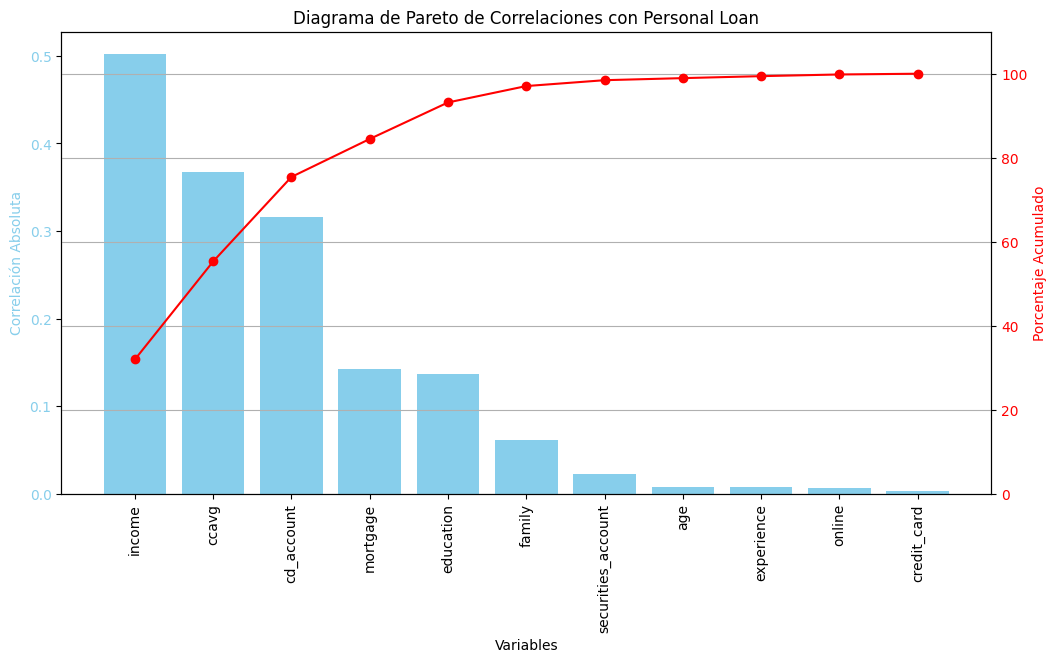

In [ ]:
# Calculate cumulative percentage
cumulative_percentage = correlations.cumsum() / correlations.sum() * 100

# Create Pareto chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for correlations
ax1.bar(correlations.index, correlations.values, color='skyblue')
ax1.set_ylabel('Correlación Absoluta', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xlabel('Variables')
plt.xticks(rotation=90)

# Line plot for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(correlations.index, cumulative_percentage, color='red', marker='o', linestyle='-')
ax2.set_ylabel('Porcentaje Acumulado', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Add title and grid
plt.title('Diagrama de Pareto de Correlaciones con Personal Loan')
plt.grid(True)

# Show plot
plt.show()

* LINEA ROJA -> LO ACUMULADO
* En este caso tomamos hasta 0.8 de porcentaje acumulado, es decir, las variables que entras hasta el el 0.8
* Cortar cuando hay un salto muy grande

In [ ]:
# Dividimos el conjunto de datos para trabajar
X = df[['income','ccavg','cd_account']]
y = df['personal_loan']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [10,15,25],
     'max_depth': [3, 6, 9],
     'min_samples_split' : [2, 3, 4]
     }
  ]

rnd_clf = RandomForestClassifier(n_jobs=-1, random_state=42)
grid_search = GridSearchCV(rnd_clf, param_grid, cv=5, #CV -> HACE EL BOSQUE N VECES
                           scoring='f1_weighted', return_train_score=True)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             param_grid=[{'max_depth': [3, 6, 9],
                          'min_samples_split': [2, 3, 4],
                          'n_estimators': [10, 15, 25]}],
             return_train_score=True, scoring='f1_weighted')

In [ ]:
modelo = grid_search.best_estimator_
f1_score(modelo.predict(X_test), y_test, average='weighted')

0.9282315217391305

## Usando la Importancia de las Variables

¿Cómo sabe el bosque que variable es importante?
* Porque esa variable aparece seguido al cortar

In [ ]:
X = df.drop(['personal_loan'], axis=1)
y = df['personal_loan']

Tomo todas las variables menos la que debo predecir y el bosque debe darme cuales son importantes y cuales no

In [ ]:
# Dividimos el conjunto de datos para trabajar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'n_estimators': [5,10,15],
     'max_depth': [3, 6, 9],
     'min_samples_split' : [2, 3, 4]
     }
  ]

rnd_clf = RandomForestClassifier(n_jobs=-1, random_state=42)
grid_search = GridSearchCV(rnd_clf, param_grid, cv=5,
                           scoring='f1_weighted', return_train_score=True)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             param_grid=[{'max_depth': [3, 6, 9],
                          'min_samples_split': [2, 3, 4],
                          'n_estimators': [5, 10, 15]}],
             return_train_score=True, scoring='f1_weighted')

In [ ]:
#Guardo el mejor modelo
modelo = grid_search.best_estimator_

In [ ]:
#Aqui se muestran las variables y su importancia
feature_importances = {name: score for name, score in zip(list(X), modelo.feature_importances_)}
feature_importances

{'age': np.float64(0.03412876089211374),
 'experience': np.float64(0.034148374656200915),
 'income': np.float64(0.3605597683136832),
 'family': np.float64(0.09815897258103763),
 'ccavg': np.float64(0.16259056158987148),
 'education': np.float64(0.17127398897074383),
 'mortgage': np.float64(0.054588468630736596),
 'securities_account': np.float64(0.005447174282476652),
 'cd_account': np.float64(0.0620421794555006),
 'online': np.float64(0.006234880959453247),
 'credit_card': np.float64(0.010826869668182195)}

In [ ]:
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted

,0
income,0.360560
education,0.171274
ccavg,0.162591
family,0.098159
cd_account,0.062042
mortgage,0.054588
experience,0.034148
age,0.034129
credit_card,0.010827
online,0.006235


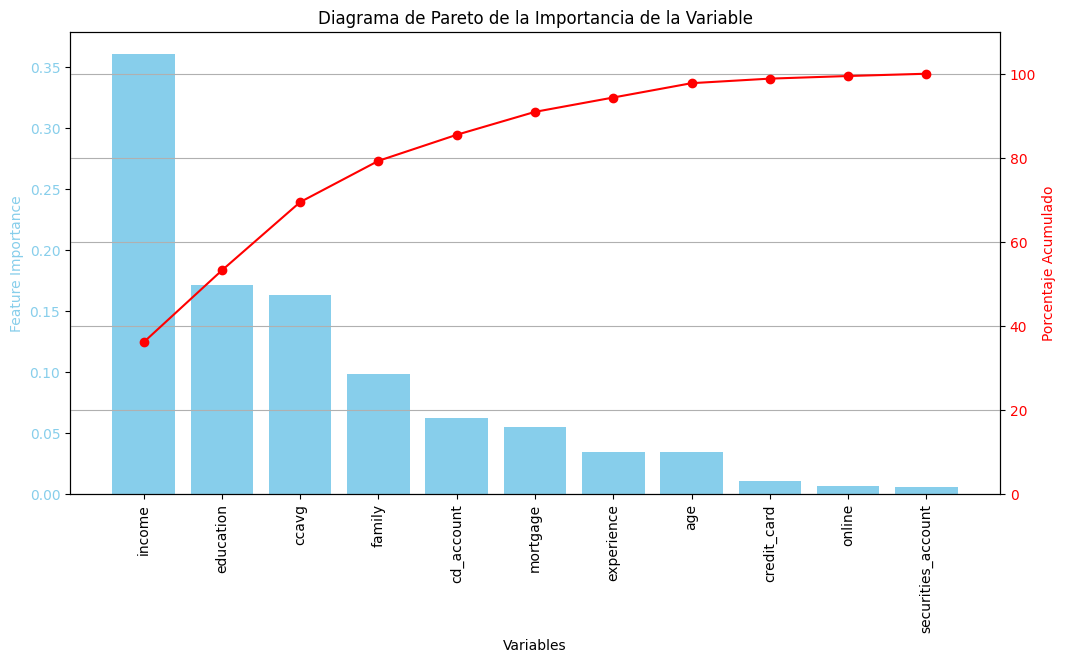

In [ ]:
# Calculate cumulative percentage
cumulative_percentage = feature_importances_sorted.cumsum() / feature_importances_sorted.sum() * 100

# Create Pareto chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for correlations
ax1.bar(feature_importances_sorted.index, feature_importances_sorted.values, color='skyblue')
ax1.set_ylabel('Feature Importance', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xlabel('Variables')
plt.xticks(rotation=90)

# Line plot for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(feature_importances_sorted.index, cumulative_percentage, color='red', marker='o', linestyle='-')
ax2.set_ylabel('Porcentaje Acumulado', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Add title and grid
plt.title('Diagrama de Pareto de la Importancia de la Variable')
plt.grid(True)

# Show plot
plt.show()

*Tomo el 80% de las variables más importantes*

In [ ]:
# Tomamos las variables necesarias y entrenamos el árbol nuevamente
X_train_reduced = X_train[['income','education','ccavg','family']]
X_test_reduced = X_test[['income','education','ccavg','family']]

In [ ]:
modelo2 = RandomForestClassifier(max_depth=9, n_estimators=15, n_jobs=-1, random_state=42)
modelo2.fit(X_train_reduced, y_train)

RandomForestClassifier(max_depth=9, n_estimators=15, n_jobs=-1, random_state=42)

In [ ]:
f1_score(modelo2.predict(X_test_reduced), y_test, average='weighted')

0.9901303550373378

## Análisis de Componentes Principales

In [ ]:
from sklearn.decomposition import PCA

# Elección arbitraria de dimensión
pca = PCA(n_components=2)  #n_componentes -> a cuantas dimensiones voy a proyectar
X_reduced = pca.fit_transform(X) #transformación
X_reduced = pd.DataFrame(X_reduced, columns=["c1", "c2"])  #solo dos variables
X_reduced

,c1,c2
0,-58.916424,-17.517171
1,-60.708605,-32.956810
2,-63.346184,-55.649157
3,-53.058756,32.889257
4,-59.407621,-21.754516
...,...,...
4995,-59.963733,-26.528166
4996,21.576888,-61.229047
4997,-61.926771,-43.462168
4998,-59.047068,-18.682182


In [ ]:
# qué porcentaje de la variabilidad se capturo.
# Lo más grande es 1
pca.explained_variance_ratio_

array([0.82132506, 0.15774781])

In [ ]:
# Podemos 'proyectar todas' y decidir el punto de corte con un diagrama de Pareto
pca = PCA(n_components=11) #R2 EN R11
X_reduced = pca.fit_transform(X)
varianza = pca.explained_variance_ratio_
varianza

array([8.21325056e-01, 1.57747806e-01, 2.05275482e-02, 1.39734364e-04,
       1.01152134e-04, 7.01739449e-05, 4.17376965e-05, 1.91024279e-05,
       1.66944409e-05, 8.05191858e-06, 2.94262803e-06])

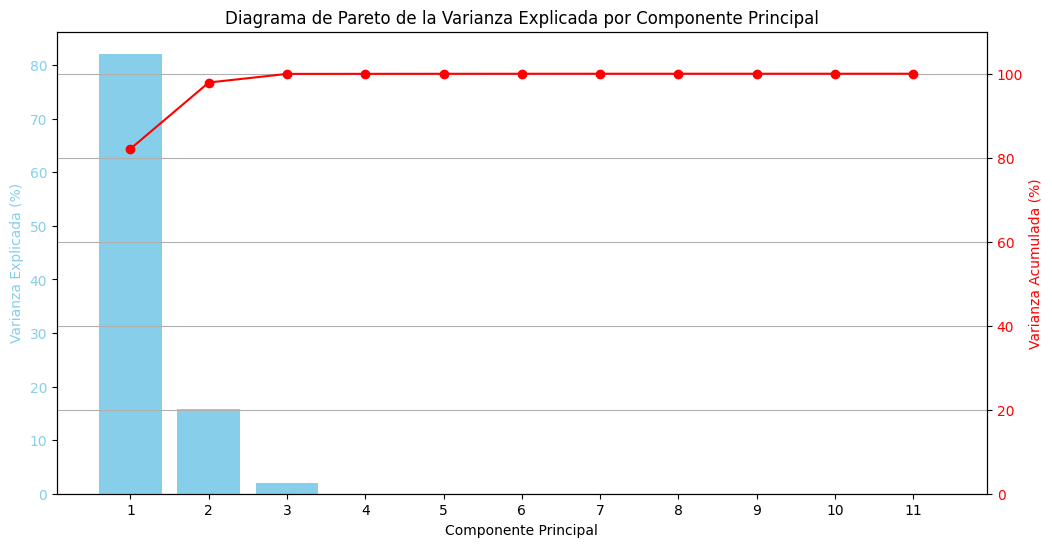

In [ ]:
# Calculate cumulative explained variance
cumulative_variance = np.cumsum(varianza) * 100

# Create Pareto chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for explained variance
ax1.bar(range(1, len(varianza) + 1), varianza * 100, color='skyblue')
ax1.set_ylabel('Varianza Explicada (%)', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xlabel('Componente Principal')
plt.xticks(range(1, len(varianza) + 1))

# Line plot for cumulative explained variance
ax2 = ax1.twinx()
ax2.plot(range(1, len(varianza) + 1), cumulative_variance, color='red', marker='o', linestyle='-')
ax2.set_ylabel('Varianza Acumulada (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Add title and grid
plt.title('Diagrama de Pareto de la Varianza Explicada por Componente Principal')
plt.grid(True)

# Show plot
plt.show()

*Combiene proyectar en proyección 3 para tener la mayoría de la variabilidad* (según la gráfica de pareto)

In [ ]:
# Elección de varianza a conservar
pca = PCA(n_components=0.99)  #Quiero conservar el 0.99 de la variabilidad
X_reduced = pca.fit_transform(X)
X_reduced = pd.DataFrame(X_reduced)
X_reduced

,0,1,2
0,-58.916424,-17.517171,-28.395146
1,-60.708605,-32.956810,-1.835153
2,-63.346184,-55.649157,-9.366827
3,-53.058756,32.889257,-14.612312
4,-59.407621,-21.754516,-16.458071
...,...,...,...
4995,-59.963733,-26.528166,-24.324473
4996,21.576888,-61.229047,-23.442321
4997,-61.926771,-43.462168,24.832103
4998,-59.047068,-18.682182,27.460742


No son varibales son dimensiones / componentes

In [ ]:
pca.explained_variance_ratio_

array([0.82132506, 0.15774781, 0.02052755])

In [ ]:
X_train_reduced, X_test_reduced, y_train, y_test = train_test_split(X_reduced, y, test_size=0.4, random_state=42)
X_val_reduced, X_test_reduced, y_val, y_test = train_test_split(X_test_reduced, y_test, test_size=0.5, random_state=42)

In [ ]:
#Entrenamos el bosque

from sklearn.ensemble import RandomForestClassifier

clf_rnd = RandomForestClassifier(n_estimators=10, random_state=42, n_jobs=-1)
clf_rnd.fit(X_train_reduced, y_train)
print(f1_score(clf_rnd.predict(X_val_reduced), y_val, average='weighted'))

0.9046781099324976


In [ ]:
# Probados la exactitud del modelo
y_pred = clf_rnd.predict(X_test_reduced)
print("F1 Score:", f1_score(y_pred, y_test, average='weighted'))

F1 Score: 0.8978214471845735


### PREDICCIÓN

In [ ]:
# Predecimos una nueva observación, pero antes hay que realizar la proyección
X_new = pd.DataFrame([{'age':35, 'experience':10, 'income':100, 'family':5, 'ccavg':5, 'education':3,
       'mortgage':0, 'securities_account':0, 'cd_account':1, 'online':1,
       'credit_card':1}])
X_new_proy = pca.transform(X_new)   #HAY QUE PROYECTAR DE R11 A DIMENSIÓN 3 (R3)
y_pred = clf_rnd.predict(X_new_proy)
y_pred = pd.DataFrame(y_pred, columns=["personal_loan"])
y_pred
#0 -> NO LE ROC

,personal_loan
0,0


# REDUCIR VARIABLES

In [137]:
df = pd.read_csv('ISCX.csv')
df

,duration,total_fpackets,total_bpackets,total_fpktl,total_bpktl,min_fpktl,min_bpktl,max_fpktl,max_bpktl,mean_fpktl,...,mean_idle,max_idle,std_idle,FFNEPD,Init_Win_bytes_forward,Init_Win_bytes_backward,RRT_samples_clnt,Act_data_pkt_forward,min_seg_size_forward,calss
0,1020586,668,1641,35692,2276876,52,52,679,1390,53.431138,...,0.0,-1,0.000000e+00,2,4194240,1853440,1640,668,32,benign
1,80794,1,1,75,124,75,124,75,124,75.000000,...,0.0,-1,0.000000e+00,2,0,0,0,1,0,benign
2,998,3,0,187,0,52,-1,83,-1,62.333333,...,0.0,-1,0.000000e+00,4,101888,-1,0,3,32,benign
3,189868,9,9,1448,6200,52,52,706,1390,160.888889,...,0.0,-1,0.000000e+00,2,4194240,2722560,8,9,32,benign
4,110577,4,6,528,1422,52,52,331,1005,132.000000,...,0.0,-1,0.000000e+00,2,155136,31232,5,4,32,benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631950,530,1,1,74,334,74,334,74,334,74.000000,...,0.0,-1,0.000000e+00,2,0,0,0,1,0,benign
631951,50240627,23,24,4767,6107,52,52,533,855,207.260870,...,9842879.0,9964749,1.196806e+05,2,317952,107008,11,23,32,GeneralMalware
631952,35471450,1,2,52,104,52,52,52,52,52.000000,...,35300000.0,35290631,0.000000e+00,2,3904,88704,1,1,32,asware
631953,41713629,12,26,1821,18643,40,40,489,1390,151.750000,...,20200000.0,32711382,1.770000e+07,2,227456,2432,23,12,20,benign


In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631955 entries, 0 to 631954
Data columns (total 80 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration                 631955 non-null  int64  
 1   total_fpackets           631955 non-null  int64  
 2   total_bpackets           631955 non-null  int64  
 3   total_fpktl              631955 non-null  int64  
 4   total_bpktl              631955 non-null  int64  
 5   min_fpktl                631955 non-null  int64  
 6   min_bpktl                631955 non-null  int64  
 7   max_fpktl                631955 non-null  int64  
 8   max_bpktl                631955 non-null  int64  
 9   mean_fpktl               631955 non-null  float64
 10  mean_bpktl               631955 non-null  float64
 11  std_fpktl                631955 non-null  float64
 12  std_bpktl                631955 non-null  float64
 13  total_fiat               631955 non-null  int64  
 14  tota

In [139]:
#valores únicos de calss
df['calss'].unique()

array(['benign', 'asware', 'GeneralMalware'], dtype=object)

In [140]:
#verificar valores nulos
df.isnull().sum()

,0
duration,0
total_fpackets,0
total_bpackets,0
total_fpktl,0
total_bpktl,0
...,...
Init_Win_bytes_backward,0
RRT_samples_clnt,0
Act_data_pkt_forward,0
min_seg_size_forward,0


In [141]:
#codificar calss
df['calss'] = df['calss'].map({'benign': 0, 'asware': 1, 'GeneralMalware': 2})
df

,duration,total_fpackets,total_bpackets,total_fpktl,total_bpktl,min_fpktl,min_bpktl,max_fpktl,max_bpktl,mean_fpktl,...,mean_idle,max_idle,std_idle,FFNEPD,Init_Win_bytes_forward,Init_Win_bytes_backward,RRT_samples_clnt,Act_data_pkt_forward,min_seg_size_forward,calss
0,1020586,668,1641,35692,2276876,52,52,679,1390,53.431138,...,0.0,-1,0.000000e+00,2,4194240,1853440,1640,668,32,0
1,80794,1,1,75,124,75,124,75,124,75.000000,...,0.0,-1,0.000000e+00,2,0,0,0,1,0,0
2,998,3,0,187,0,52,-1,83,-1,62.333333,...,0.0,-1,0.000000e+00,4,101888,-1,0,3,32,0
3,189868,9,9,1448,6200,52,52,706,1390,160.888889,...,0.0,-1,0.000000e+00,2,4194240,2722560,8,9,32,0
4,110577,4,6,528,1422,52,52,331,1005,132.000000,...,0.0,-1,0.000000e+00,2,155136,31232,5,4,32,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
631950,530,1,1,74,334,74,334,74,334,74.000000,...,0.0,-1,0.000000e+00,2,0,0,0,1,0,0
631951,50240627,23,24,4767,6107,52,52,533,855,207.260870,...,9842879.0,9964749,1.196806e+05,2,317952,107008,11,23,32,2
631952,35471450,1,2,52,104,52,52,52,52,52.000000,...,35300000.0,35290631,0.000000e+00,2,3904,88704,1,1,32,1
631953,41713629,12,26,1821,18643,40,40,489,1390,151.750000,...,20200000.0,32711382,1.770000e+07,2,227456,2432,23,12,20,0


In [142]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# CORTE OPTIMO ES 8 - MEJOR METODO ES PSA

In [158]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest Classifier
forest_clf = RandomForestClassifier(random_state=42)

# Train the model
forest_clf.fit(X_train, y_train)

ValueError: Input y contains NaN.